---
---
# MBA - 2026
## Dirección Financiera

### Profesor Fernando Díaz Hurtado.
---


# 🇺🇸 LA Relación Riesgo-Retorno: Instrumentos financieros norteamericanos

En esta sección trabajaremos con información financiera del mercado estadounidense, incluyendo **índices accionarios** y **bonos del Tesoro de Estados Unidos**.

## 📈 Índices accionarios disponibles

Un **índice accionario** es un indicador que resume el comportamiento de un grupo de acciones. Su valor se construye a partir de los precios o de la capitalización bursátil de las empresas que lo componen.

Los índices permiten observar la evolución general de un mercado o de un segmento específico, por ejemplo, empresas grandes, medianas o pequeñas. También se utilizan como **benchmarks**, es decir, como referencias para comparar el desempeño de una cartera de inversión.

El paquete **tidyquant** permite consultar la composición de distintos índices mediante la función `tq_index()`.

Los índices disponibles son:

* **`DOW` — Dow Jones Industrial Average:** reúne 30 grandes empresas estadounidenses. Es uno de los indicadores bursátiles más tradicionales y ampliamente difundidos.

* **`DOWGLOBAL` — Dow Jones Global Index:** representa empresas de distintos países y permite observar el desempeño general del mercado accionario global.

* **`SP400` — S&P MidCap 400:** incluye empresas estadounidenses de mediana capitalización. Permite analizar el segmento intermedio entre las grandes empresas del S&P 500 y las empresas pequeñas del S&P 600.

* **`SP500` — S&P 500:** agrupa aproximadamente 500 grandes empresas estadounidenses. Es uno de los principales indicadores del mercado accionario de Estados Unidos y suele utilizarse como aproximación del **portafolio de mercado**.

* **`SP600` — S&P SmallCap 600:** incluye empresas estadounidenses de menor capitalización bursátil y permite estudiar el comportamiento del segmento de empresas pequeñas o *small caps*.

> 💡 **Importancia:** los índices accionarios permiten medir el desempeño de distintos segmentos del mercado, comparar inversiones y construir referencias para evaluar una cartera.



## 🏛️ Bonos del Tesoro de Estados Unidos

Los **bonos del Tesoro de Estados Unidos** son instrumentos de deuda emitidos por el gobierno federal. Debido a su elevada liquidez y bajo riesgo de incumplimiento, sus rendimientos suelen utilizarse como referencia para las tasas de interés del mercado y como aproximación de la **tasa libre de riesgo**.

Los principales instrumentos son:

* **Treasury Bills (T-Bills):** instrumentos de corto plazo con vencimientos de **4, 8, 13, 17, 26 y 52 semanas**. Se venden con descuento respecto de su valor nominal y no pagan cupones periódicos. La rentabilidad del inversionista corresponde a la diferencia entre el precio de compra y el valor recibido al vencimiento.

* **Treasury Notes (T-Notes):** instrumentos de mediano plazo con vencimientos de **2, 3, 5, 7 y 10 años**. Pagan intereses mediante cupones semestrales y devuelven el principal al vencimiento.

* **Treasury Bonds (T-Bonds):** instrumentos de largo plazo con vencimientos de **20 y 30 años**. También pagan cupones semestrales y reembolsan el valor principal al vencimiento.

* **Treasury Inflation-Protected Securities (TIPS):** instrumentos cuyo principal se ajusta de acuerdo con la inflación. Se emiten con vencimientos de **5, 10 y 30 años** y están diseñados para proteger el poder adquisitivo del inversionista.

* **Floating Rate Notes (FRNs):** instrumentos con vencimiento de **2 años** cuya tasa de interés es variable. El cupón se ajusta periódicamente de acuerdo con una tasa de referencia de corto plazo.

> 💡 **Importancia:** los rendimientos de los bonos del Tesoro permiten analizar la estructura temporal de tasas de interés, estimar la tasa libre de riesgo, valorar activos financieros y estudiar las expectativas del mercado sobre inflación, crecimiento económico y política monetaria.



## 📦 Cargando las librerías

Antes de comenzar el análisis, cargaremos los paquetes de **R** que utilizaremos a lo largo del notebook:

* **`tidyquant`**: descarga y manipulación de datos financieros.
* **`dplyr`**: transformación y organización de bases de datos.
* **`ggplot2`**: construcción de gráficos.
* **`lubridate`**: manejo de fechas y períodos de tiempo.

> 💡 Las librerías deben instalarse una sola vez, pero deben cargarse cada vez que se inicia una nueva sesión de R.


In [1]:
install.packages(c("tidyquant", "dplyr", "ggplot2", "lubridate"), quiet = TRUE)

In [2]:
suppressWarnings(suppressPackageStartupMessages({
  library(tidyquant)
  library(dplyr)
  library(ggplot2)
  library(lubridate)
}))

---
# 📊 El paquete `tidyquant`

<p align="center">
  <a href="https://business-science.github.io/tidyquant/" target="_blank">
    <img src="https://business-science.github.io/tidyquant/logo.png"
         alt="Logo de tidyquant"
         width="220">
  </a>
</p>

[`tidyquant`](https://business-science.github.io/tidyquant/) es un paquete de **R** diseñado para facilitar la obtención, manipulación, visualización y análisis de datos financieros y series temporales dentro del flujo de trabajo de `tidyverse`.

El paquete integra herramientas provenientes de librerías especializadas como `quantmod`, `xts`, `zoo`, `TTR` y `PerformanceAnalytics`, pero permite trabajar con ellas utilizando estructuras de datos y funciones compatibles con `dplyr`, `tidyr` y `ggplot2`.

Entre sus principales funcionalidades se encuentran:

* 🌐 **Descargar datos financieros y económicos** mediante `tq_get()`.
* 🏢 **Consultar las empresas que componen índices bursátiles** mediante `tq_index()`.
* 🔄 **Transformar series financieras** mediante `tq_mutate()` y `tq_transmute()`.
* 📈 **Construir visualizaciones financieras** utilizando `ggplot2`.
* 💼 **Analizar retornos y carteras de inversión** mediante funciones de desempeño y agregación de portafolios.

> 🔗 **Documentación oficial:** [business-science.github.io/tidyquant](https://business-science.github.io/tidyquant/)


## 📈 Índices accionarios disponibles


In [3]:
# Esta función muestra los índices accionarios disponibles 
# para consultar mediante tq_index().

tq_index_options()

[1] "DOW"       "DOWGLOBAL" "SP400"     "SP500"     "SP600"

---
# 📈 Índice S&P 500

<p align="center">
  <a href="https://en.wikipedia.org/wiki/S%26P_500" target="_blank">
    <img src="https://upload.wikimedia.org/wikipedia/commons/c/c4/S%26P_Dow_Jones_Indices_logo.svg"
         alt="S&P Dow Jones Indices logo" width="300"/>
  </a>
</p>

El **S&P 500** es un índice accionario diseñado para medir el desempeño de las empresas de gran capitalización del mercado estadounidense. Incluye 500 compañías líderes —aunque puede contener más de 500 acciones debido a empresas con distintas clases accionarias— y cubre aproximadamente el **80 % de la capitalización bursátil disponible** de Estados Unidos. Por esta razón, se considera una de las principales referencias del mercado accionario estadounidense.

## 🏛️ Administración y selección de empresas

El índice es elaborado y administrado por **S&P Dow Jones Indices**. Su composición no se determina simplemente seleccionando las 500 empresas más grandes: un comité evalúa criterios de elegibilidad relacionados con capitalización bursátil, liquidez, flotación pública, domicilio, cotización en mercados estadounidenses, viabilidad financiera y representación sectorial.

La composición se revisa continuamente, mientras que sus ponderaciones y acciones en circulación se actualizan en los rebalanceos trimestrales de **marzo, junio, septiembre y diciembre**.

## ⚖️ ¿Es un índice *value weighted*?

Sí, en el sentido tradicional de que las empresas se ponderan según su **valor de mercado**. Sin embargo, la denominación técnicamente correcta es:

> **Índice ponderado por capitalización bursátil ajustada por flotación libre.**

Asigna mayor peso a las empresas con mayor capitalización bursátil disponible para inversión.

La capitalización bursátil ajustada (***Float-adjusted Market Capitalization***) de la empresa $i$ se calcula como:

$$
FMC_i=P_i\times Q_i\times IWF_i
$$

donde:

* $P_i$ es el precio de la acción;
* $Q_i$ es el número total de acciones en circulación;
* $IWF_i$ es el *Investable Weight Factor*, que representa la proporción de acciones considerada disponible para los inversionistas.

El peso de cada empresa es:

$$
w_i=
\frac{FMC_i}
{\sum_{j=1}^{N}FMC_j}
$$

Por lo tanto, una empresa con mayor capitalización ajustada por flotación libre tiene una mayor incidencia sobre el retorno del índice.

## 🌊 ¿Qué es el *free float*?

El **free float** o flotación libre corresponde a la proporción de acciones que se encuentra efectivamente disponible para negociación pública.

Se excluyen, entre otras, participaciones estratégicas o bloques de control mantenidos por:

* fundadores y altos ejecutivos;
* gobiernos y organismos públicos;
* empresas matrices o accionistas controladores;
* inversionistas institucionales;
* fundaciones corporativas;
* otros propietarios estratégicos cuyas acciones no se negocian regularmente.

El ajuste por flotación busca que la ponderación de cada compañía refleje mejor la cantidad de acciones que los inversionistas realmente pueden comprar y vender.

### 📊 ¿Cuál es el *free float* promedio?

No existe en la ficha pública del índice una cifra oficial única para el **free float promedio del S&P 500**. Además, este valor cambia cuando varían las estructuras de propiedad, las acciones en circulación o los componentes del índice.

> ⚠️ No debe inferirse el *free float* promedio a partir del peso de las empresas en el índice, porque dicho peso combina precio, acciones en circulación y flotación disponible.

En cualquier caso, el free float promedio del S&P 500 es alto, estimándose cercano al 90%.

## 📏 Concentración del índice

Debido a su metodología de ponderación, las empresas más grandes tienen una influencia considerable. Al **29 de mayo de 2026**, el componente de mayor peso representaba aproximadamente **7,5 %** del índice y los diez componentes principales concentraban alrededor de **36,4 %**. Estas cifras cambian con los precios de mercado.

## 📈 ¿Por qué es importante?

El S&P 500 se utiliza como:

* indicador del desempeño de las grandes empresas estadounidenses;
* referencia o *benchmark* para evaluar fondos y carteras;
* base para fondos indexados, ETF, futuros y opciones;
* aproximación empírica del portafolio de mercado;
* referencia para estimar retornos exigidos y primas de riesgo.

### 🧮 El S&P 500 como benchmark en el CAPM

El **Capital Asset Pricing Model (CAPM)** establece que:

$$
E(R_i)=
R_f+
\beta_i
\left[
E(R_M)-R_f
\right]
$$

donde:

* $R_f$ es la tasa libre de riesgo;
* $E(R_M)-R_f$ es la prima de riesgo del mercado;
* $\beta_i$ mide la sensibilidad del activo frente al mercado.

La beta se calcula como:

$$
\beta_i=
\frac{\operatorname{Cov}(R_i,R_M)}
{\operatorname{Var}(R_M)}
$$

En teoría, $R_M$ debería corresponder al retorno del **portafolio de mercado**, compuesto por todos los activos riesgosos disponibles.

Como ese portafolio no es directamente observable, el S&P 500 se utiliza habitualmente como una aproximación porque posee amplia cobertura del mercado estadounidense, elevada liquidez, diversificación sectorial y una extensa historia de datos.

> ⚠️ **Precisión conceptual:** el S&P 500 no es el portafolio de mercado teórico del CAPM. No incluye empresas pequeñas fuera del índice, acciones extranjeras, bonos, bienes raíces ni otros activos riesgosos.

### 💻 Información del índice en `tidyquant`

La composición del S&P 500 puede obtenerse mediante:

```r
sp500 <- tq_index("SP500")
```

El objeto contiene información sobre las empresas que componen el índice, incluyendo sus símbolos bursátiles, nombres, sectores y ponderaciones disponibles en la fuente utilizada por `tidyquant`.


In [4]:
sp500 <- suppressMessages(tq_index('SP500'))

top_n <- 15

sp500_top <- sp500 |>
  arrange(desc(weight)) |>
  slice_head(n = top_n) |>
  transmute(
    `#` = row_number(),
    Símbolo = symbol,
    Empresa = company,
    `Peso (%)` = round(weight * 100, 2)
  )

suppressPackageStartupMessages(library(knitr))
suppressPackageStartupMessages(library(IRdisplay))

display_html(as.character(
  kable(sp500_top, format = "html", align = c("c", "l", "l", "r"))
))

cat(sprintf(
  "A la fecha, las %d empresas de mayor peso concentran %.1f%% del índice (%d componentes en total).",
  top_n, sum(sp500_top[["Peso (%)"]]), nrow(sp500)
))

#,Símbolo,Empresa,Peso (%)
1,NVDA,NVIDIA CORP,7.94
2,AAPL,APPLE INC,7.01
3,MSFT,MICROSOFT CORP,5.41
4,AMZN,AMAZON.COM INC,3.92
5,GOOGL,ALPHABET INC CL A,3.05
6,AVGO,BROADCOM INC,2.59
7,GOOG,ALPHABET INC CL C,2.43
8,META,META PLATFORMS INC CLASS A,1.81
9,MU,MICRON TECHNOLOGY INC,1.59
10,LLY,ELI LILLY + CO,1.53


A la fecha, las 15 empresas de mayor peso concentran 43.8% del índice (505 componentes en total).

## 📈 Evolución del S&P 500 a través del tiempo

Una vez obtenida la composición del índice, podemos analizar su comportamiento histórico mediante la serie de precios del **S&P 500**.

Este análisis permite observar:

* la tendencia de largo plazo del mercado accionario estadounidense;
* períodos de expansión y contracción;
* episodios de alta volatilidad;
* caídas asociadas a crisis financieras o económicas;
* la recuperación posterior del mercado.

Para descargar la serie histórica de los últimos 30 años, utilizaremos la función `tq_get()` del paquete `tidyquant` y el símbolo bursátil **`^GSPC`**, empleado habitualmente para identificar al índice S&P 500 en Yahoo Finance.


> 💡 Es importante distinguir entre el **nivel del índice** y su **retorno**. El nivel muestra el valor acumulado del S&P 500 en cada fecha, mientras que el retorno mide su variación porcentual entre dos períodos.


In [5]:
# Set date range: last 30 years from today
start_date <- today() - years(30)
end_date <- today()

In [6]:
# Download SP500 index data
sp500_data <- tq_get("^GSPC", 
                     from = start_date, 
                     to = end_date)

In [7]:
suppressPackageStartupMessages(library(knitr))
suppressPackageStartupMessages(library(IRdisplay))

display_html(as.character(
  kable(head(sp500_data), format = "html", digits = 2, format.args = list(big.mark = ","))
))

symbol,date,open,high,low,close,volume,adjusted
^GSPC,1996-08-20,666.58,666.99,665.15,665.69,"334,960,000",665.69
^GSPC,1996-08-21,665.69,665.69,662.16,665.07,"348,820,000",665.07
^GSPC,1996-08-22,665.07,670.68,664.88,670.68,"354,950,000",670.68
^GSPC,1996-08-23,670.68,670.68,664.93,667.03,"308,010,000",667.03
^GSPC,1996-08-26,667.03,667.03,662.36,663.88,"281,430,000",663.88
^GSPC,1996-08-27,663.88,666.40,663.50,666.40,"310,520,000",666.40


Grafiquemos el precio de cierre, ajustado por dividendos y splits:

Utilizamos el precio de cierre **ajustado** (`adjusted`) en lugar del precio de cierre bruto (`close`) porque este último puede distorsionar el retorno real del activo:

* **Splits (divisiones de acciones):** si una empresa hace un split 2×1, el precio bruto cae a la mitad de un día para otro, aunque el valor total en manos del inversionista no cambia. El precio ajustado reescala la serie histórica para que se mantenga continua.
* **Dividendos:** en la fecha ex-dividendo, el precio bruto cae aproximadamente en el monto del dividendo pagado —ese valor no se perdió, simplemente se distribuyó como efectivo—. El precio ajustado corrige esta caída, reflejando el retorno total (variación de precio + dividendos reinvertidos).

> 💡 En este caso particular, `^GSPC` es un **índice de precios**, no una acción individual: no tiene splits ni dividendos propios, por lo que `adjusted` y `close` suelen ser prácticamente idénticos aquí. Aun así, usamos `adjusted` como buena práctica, ya que el mismo patrón (`tq_get()` + retornos sobre `adjusted`) se reutiliza más adelante con acciones individuales que sí pagan dividendos, donde la diferencia sí es relevante.

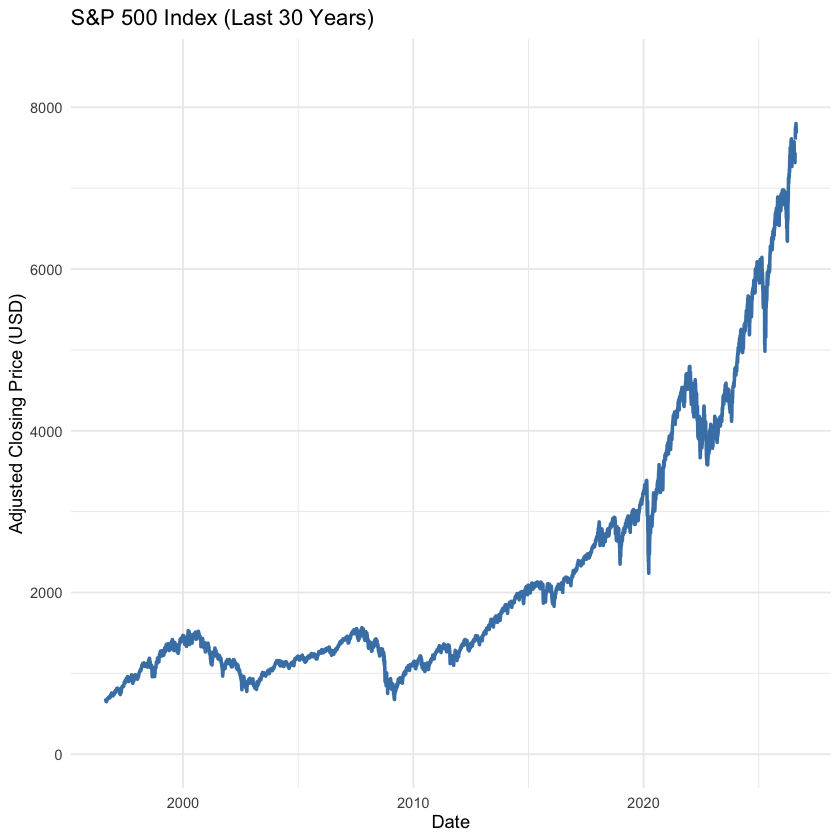

In [8]:
# Plot Adjusted Close Price
y_top <- max(sp500_data$adjusted, na.rm = TRUE)

sp500_data |>
  ggplot(aes(x = date, y = adjusted)) +
  geom_line(color = "steelblue", linewidth = 1) +
  scale_y_continuous(limits = c(0, y_top * 1.08)) +
  labs(
    title = "S&P 500 Index (Last 30 Years)",
    x = "Date",
    y = "Adjusted Closing Price (USD)"
  ) +
  theme_minimal()

Marquemos en el gráfico algunas de las principales caídas de mercado de los últimos 30 años, junto con el retorno diario registrado en el peor día de cada episodio:

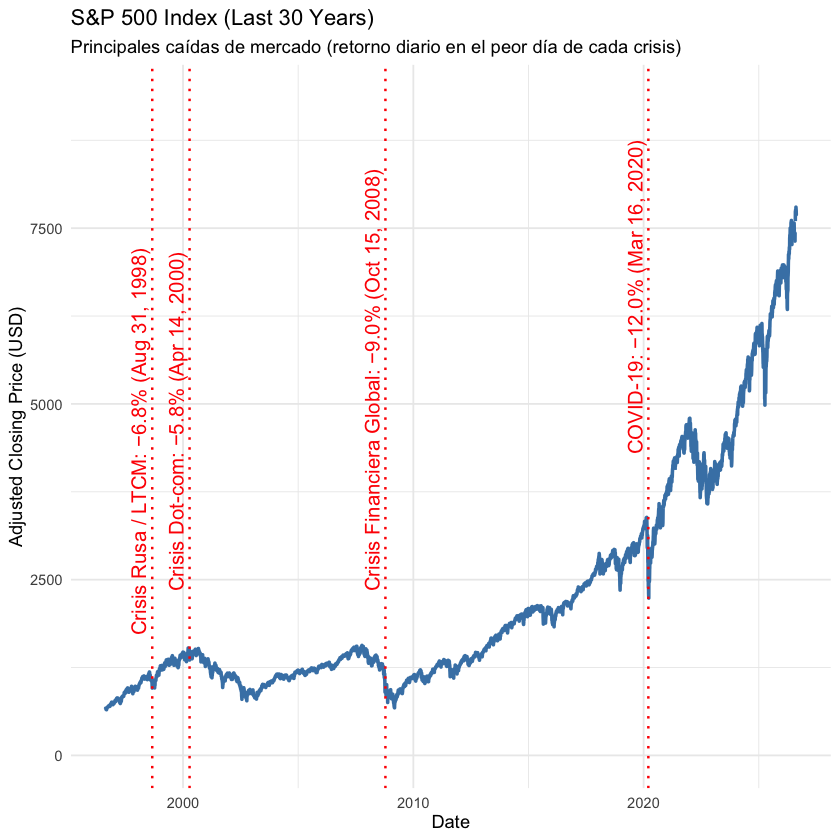

In [9]:
# Principales caídas de mercado (peor retorno diario dentro de cada crisis)
crash_events <- tibble(
  date  = as.Date(c("1998-08-31", "2000-04-14", "2008-10-15", "2020-03-16")),
  event = c("Crisis Rusa / LTCM", "Crisis Dot-com", "Crisis Financiera Global", "COVID-19"),
  ret   = c(-0.0680, -0.0583, -0.0903, -0.1198),
  y_frac = c(0.22, 0.30, 0.30, 0.55)
)

y_top <- max(sp500_data$adjusted, na.rm = TRUE)

crash_events <- crash_events |>
  mutate(
    label = sprintf("%s: −%.1f%% (%s)", event, abs(ret) * 100, format(date, "%b %d, %Y")),
    y_pos = y_frac * y_top
  )

sp500_data |>
  ggplot(aes(x = date, y = adjusted)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_vline(data = crash_events, aes(xintercept = date),
             color = "red", linetype = "dotted", linewidth = 0.7) +
  geom_text(data = crash_events,
            aes(x = date, y = y_pos, label = label),
            color = "red", angle = 90, hjust = 0, vjust = -0.4, size = 4.3) +
  scale_y_continuous(limits = c(0, y_top * 1.20)) +
  labs(
    title = "S&P 500 Index (Last 30 Years)",
    subtitle = "Principales caídas de mercado (retorno diario en el peor día de cada crisis)",
    x = "Date",
    y = "Adjusted Closing Price (USD)"
  ) +
  theme_minimal()

---

# 🧭 Índices, instrumentos y clases de activos

Ahora, para el mismo período de tiempo, descargaremos información del **Dow Jones Industrial Average**, el **S&P 600** y la **tasa del Tesoro de Estados Unidos a 10 años con vencimiento constante**.

Es importante distinguir entre un **activo financiero**, una **clase de activo**, un **índice** y una **tasa de rendimiento**:

* Un **activo financiero** es un instrumento específico, como una acción o un bono.
* Una **clase de activo** agrupa instrumentos con características económicas y financieras similares.
* Un **índice** representa el comportamiento de un conjunto de activos.
* Una **tasa de rendimiento** refleja el retorno exigido por el mercado para un determinado instrumento o plazo.

En este caso:

* El **S&P 500**, el **S&P 600** y el **Dow Jones Industrial Average** son índices accionarios. Los tres representan distintos segmentos de la clase de activo **renta variable**.
* Los bonos del Tesoro de Estados Unidos pertenecen a la clase de activo **renta fija**.
* La serie del Treasury a 10 años con vencimiento constante no corresponde al precio de un bono específico, sino a una **tasa de rendimiento de referencia** del mercado de renta fija.

El **S&P 500** representa principalmente empresas de gran capitalización, el **S&P 600** representa empresas de pequeña capitalización y el **Dow Jones Industrial Average** reúne 30 grandes compañías estadounidenses.

Por lo tanto, estos índices no constituyen clases de activos distintas. Son diferentes referencias o *benchmarks* dentro de la renta variable estadounidense.

> 💡 El objetivo será comparar el comportamiento de distintas activos, con el fin de estudiar la relación de largo plazo entre **riesgo y retorno**.



### 📊 Diferencias entre el S&P 500, S&P 600 y el Dow

| Índice        | ¿Qué representa?                                                                 | Tipo de empresas             | Método de cálculo                      |
|---------------|----------------------------------------------------------------------------------|-------------------------------|----------------------------------------|
| **S&P 500**   | Las 500 mayores empresas de EE.UU. por capitalización bursátil.                  | **Large Cap** (grandes)       | Ponderado por capitalización de mercado |
| **S&P 600**   | 600 empresas pequeñas seleccionadas por su estabilidad y liquidez.               | **Small Cap** (pequeñas)      | Ponderado por capitalización de mercado |
| **Dow Jones** | 30 grandes empresas industriales líderes de EE.UU., muy conocidas.               | **Large Cap** (pero solo 30)  | **Ponderado por precio**, no por capitalización |


## 📈 Tendencias temporales de los índices y del Treasury

A continuación, compararemos la evolución temporal del **S&P 500**, el **S&P 600**, el **Dow Jones Industrial Average** y los **Treasury a 10 años**.

Para facilitar la comparación:

* Consideraremos el período que comienza en el año **2005**.
* Representaremos todas las series en un mismo gráfico.
* Normalizaremos cada serie a **100 en la primera fecha disponible**, de modo que todas comiencen en el mismo punto.

La normalización se calcula como:

$$X_{i,t}^{(100)}=\frac{X_{i,t}}{X_{i,0}}\times 100$$

donde:

* $X_{i,t}$ es el nivel del índice o el precio aproximado del instrumento $i$ en la fecha $t$;
* $X_{i,0}$ es su valor en la primera fecha de la muestra;
* $X_{i,t}^{(100)}$ es el valor normalizado.

De esta manera, los valores posteriores representan la evolución acumulada de cada serie respecto de su nivel inicial. Por ejemplo, un valor de 180 indica un aumento de **80 %**, mientras que un valor de 75 indica una disminución de **25 %**.




> 💡 **Objetivo del análisis:** la comparación permitirá estudiar la relación de largo plazo entre **riesgo y retorno**. En particular, observaremos si los segmentos del mercado que presentan mayores fluctuaciones  también generan retornos acumulados más elevados durante el período analizado.


### ⚖️ Riesgo y retorno esperados *a priori*

Antes de observar los datos, vale la pena formular una expectativa inicial:

> **¿Qué instrumentos deberían presentar mayor riesgo y, en compensación, un mayor retorno esperado?**

| Índice o instrumento   | Segmento representado                                           | Riesgo esperado *a priori* | Retorno esperado *a priori* |
| ---------------------- | --------------------------------------------------------------- | -------------------------: | --------------------------: |
| **S&P 500**            | Empresas grandes y líderes de sus industrias (*large caps*)     |                   Moderado |                    Moderado |
| **Dow Jones**          | 30 empresas grandes, consolidadas y altamente reconocidas       |              Moderado-bajo |               Moderado-bajo |
| **S&P 600**            | Empresas estadounidenses de menor capitalización (*small caps*) |                       Alto |                        Alto |
| **Treasury a 10 años** | Deuda soberana de Estados Unidos                                |                       Bajo |                        Bajo |

#### 🔍 ¿Por qué las empresas pequeñas deberían ser más riesgosas?

Fama y French (1992, 1993) documentaron que las empresas de menor capitalización bursátil tendían, en promedio, a presentar retornos superiores a los de las empresas grandes. Este patrón dio origen al denominado **factor de tamaño**, representado en su modelo de tres factores por:

$$SMB=\text{Small Minus Big}$$

El factor $SMB$ mide la diferencia entre el retorno de carteras compuestas por empresas pequeñas y el retorno de carteras formadas por empresas grandes.

Una interpretación posible es que las empresas pequeñas deben ofrecer una mayor rentabilidad esperada para compensar riesgos como los siguientes:

* **Menor diversificación operativa:** suelen depender de menos productos, clientes o mercados geográficos.
* **Menor liquidez bursátil:** sus acciones se transan con menor volumen, por lo que puede ser más difícil comprar o vender posiciones importantes sin afectar el precio.
* **Mayor vulnerabilidad financiera:** generalmente poseen menor acceso al crédito y menos capacidad para absorber períodos prolongados de pérdidas.
* **Mayor sensibilidad al ciclo económico:** sus resultados pueden deteriorarse con mayor intensidad durante recesiones o restricciones financieras.
* **Menor cobertura de analistas:** existe menos información pública y puede aumentar la asimetría de información.
* **Mayor incertidumbre sobre sus flujos futuros:** suelen presentar modelos de negocio menos consolidados y resultados más variables.

> ⚠️ La existencia histórica del factor tamaño no implica que las *small caps* superen a las empresas grandes en todos los períodos. Además, continúa existiendo debate sobre si la prima de tamaño constituye una compensación por riesgo, el resultado de problemas de medición o una anomalía del mercado.

Por el contrario, el **S&P 500** y el **Dow Jones** están compuestos principalmente por empresas grandes y consolidadas. Estas compañías suelen presentar:

* mayor diversificación de sus operaciones;
* mayor acceso a financiamiento;
* acciones con mayor liquidez;
* mayor cobertura de analistas;
* mayor capacidad para enfrentar perturbaciones económicas.

Estas características deberían reducir su riesgo relativo respecto de las empresas pequeñas, aunque siguen expuestas al riesgo sistemático del mercado accionario.

#### 🏛️ ¿Por qué el Treasury debería presentar menor riesgo?

Los títulos del Tesoro de Estados Unidos están respaldados por la capacidad del gobierno federal para recaudar impuestos y emitir deuda. Por esta razón, su riesgo de incumplimiento suele considerarse muy bajo.

Sin embargo, un Treasury a 10 años **no está completamente libre de riesgo**. Su precio puede fluctuar debido a:

* cambios en las tasas de interés;
* variaciones en las expectativas de inflación;
* cambios en el horizonte de inversión;
* riesgo de reinversión de los cupones.

En particular, cuando las tasas de interés aumentan, el precio del bono disminuye; cuando las tasas caen, su precio aumenta.

> 💡 En el CAPM, la tasa libre de riesgo suele aproximarse mediante un instrumento del Tesoro de corto plazo cuyo vencimiento sea coherente con el horizonte de análisis. El Treasury a 10 años se utiliza con frecuencia como referencia de largo plazo, pero está expuesto a riesgo de tasa de interés.

#### 🎯 Hipótesis que contrastaremos

Si los mercados compensan a los inversionistas por asumir mayor riesgo, esperamos observar, en términos generales, el siguiente orden en los retornos:

$$\text{Treasury}<\text{Dow Jones}\approx\text{S\&P 500}<\text{S\&P 600}$$
Este orden debería manifestarse tanto en la **volatilidad** como en el **retorno promedio de largo plazo**, aunque no necesariamente en todos los subperíodos.

> 💡 **Objetivo empírico:** comprobaremos si los instrumentos que presentan mayor riesgo (**volatilidad**) y pérdidas potenciales también ofrecen retornos promedio más elevados durante el período analizado.


symbol,date,open,high,low,close,volume,adjusted,label
^TNX,2026-08-12,NA,NA,NA,NA,NA,4.68,10Y Treasury
^TNX,2026-08-13,NA,NA,NA,NA,NA,4.63,10Y Treasury
^TNX,2026-08-14,NA,NA,NA,NA,NA,4.68,10Y Treasury
^TNX,2026-08-17,NA,NA,NA,NA,NA,4.72,10Y Treasury
^TNX,2026-08-18,NA,NA,NA,NA,NA,4.71,10Y Treasury
^TNX,2026-08-19,NA,NA,NA,NA,NA,4.65,10Y Treasury


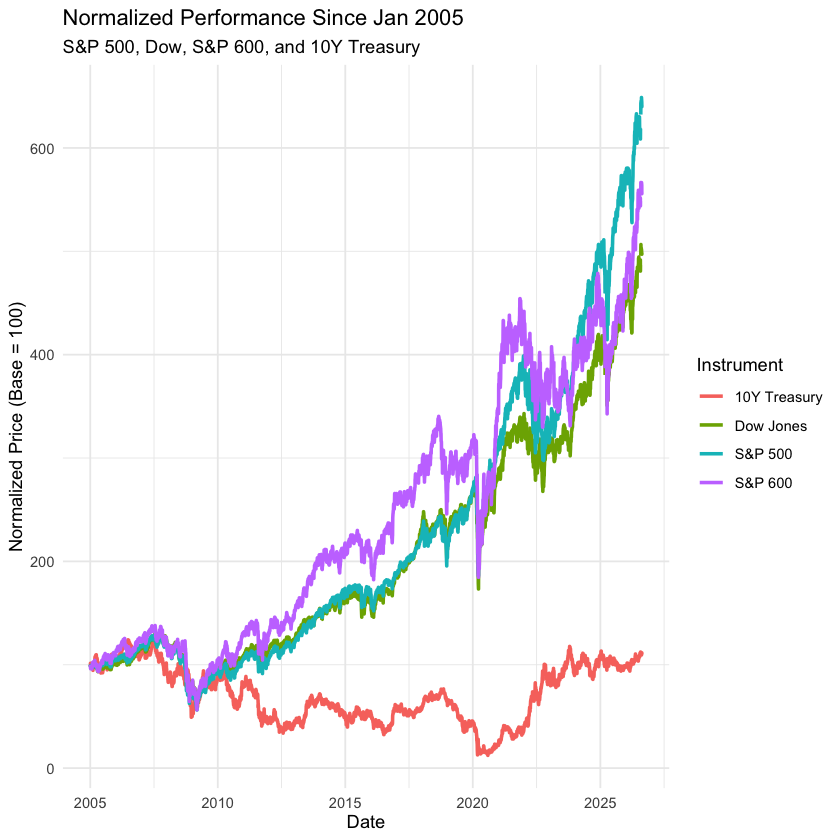

In [10]:

# Tickers
tickers <- c("^GSPC", "^DJI", "^SP600", "^TNX")

# Human-readable labels
labels <- c("^GSPC" = "S&P 500",
            "^DJI" = "Dow Jones",
            "^SP600" = "S&P 600",
            "^TNX" = "10Y Treasury")

# Set custom date range
start_date <- as.Date("2005-01-01")
end_date <- today()

# Download equity/index data from Yahoo Finance
equity_tickers <- setdiff(tickers, "^TNX")
market_data <- tq_get(equity_tickers,
                      from = start_date,
                      to = end_date,
                      get = "stock.prices")

# Yahoo Finance no longer serves long historical daily data for ^TNX (only
# the last ~20 trading days, regardless of the requested range), so we get
# the 10-year Treasury yield directly from FRED (DGS10) instead
tnx_fred <- read.csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10")
tnx_fred <- tnx_fred |>
  transmute(symbol = "^TNX",
            date = as.Date(observation_date),
            adjusted = DGS10) |>
  filter(date >= start_date, date <= end_date, !is.na(adjusted))

# Add labels
market_data <- bind_rows(market_data, tnx_fred) |>
  mutate(label = labels[symbol])

# Normalize to 100 at start date
normalized_data <- market_data |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    base_value = first(adjusted),
    norm_price = adjusted / base_value * 100
  ) |>
  ungroup()

# Plot
ggplot(normalized_data, aes(x = date, y = norm_price, color = label)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Normalized Performance Since Jan 2005",
    subtitle = "S&P 500, Dow, S&P 600, and 10Y Treasury",
    x = "Date",
    y = "Normalized Price (Base = 100)",
    color = "Instrument"
  ) +
  theme_minimal()

suppressPackageStartupMessages(library(knitr))
suppressPackageStartupMessages(library(IRdisplay))

display_html(as.character(
  kable(tail(market_data), format = "html", digits = 2, format.args = list(big.mark = ","))
))

### ⚠️ Precaución metodológica

Tal como se observa en la tabla anterior, la serie del Treasury a 10 años está expresada como una **tasa de rendimiento anual en puntos porcentuales**, no como el precio de un bono. Por ejemplo, un valor de `4.25` representa una tasa anual de:

$$r_t=\frac{4.25}{100}=0.0425$$

Esto significa que la serie no es directamente comparable con los índices accionarios, los cuales están expresados como niveles de precios.

Para obtener una medida aproximada del precio, podemos suponer un instrumento cupón cero con:

* valor nominal igual a 100;
* vencimiento de 10 años;
* tasa de descuento igual al rendimiento observado en cada fecha.

Bajo estos supuestos, el precio aproximado es:

$$P_t=\frac{100}{(1+r_t)^{10}}$$

donde:

* $P_t$ es el precio aproximado en la fecha $t$;
* $r_t$ es la tasa anual expresada en formato decimal;
* 10 corresponde al número de años hasta el vencimiento;
* 100 es el valor nominal del instrumento.

Si la variable descargada se encuentra expresada en puntos porcentuales, la fórmula que debe aplicarse es:

$$P_t=\frac{100}{\left(1+\frac{y_t}{100}\right)^{10}}$$

donde $y_t$ es la tasa del Treasury a 10 años informada en puntos porcentuales.

> 💡 **Relación precio–tasa:** cuando la tasa de interés aumenta, el valor presente de los flujos futuros disminuye y, por lo tanto, el precio aproximado del bono cae. Cuando la tasa disminuye, el precio aumenta.

> ⚠️ **Limitación:** esta transformación no representa el precio exacto de un Treasury Note a 10 años. Los Treasury Notes reales pagan cupones semestrales, mientras que la fórmula supone un instrumento cupón cero. Además, la serie de vencimiento constante es una tasa construida por interpolación y no corresponde necesariamente al rendimiento de un único bono que mantengamos durante todo el período.


Volvamos a hacer el gráfico:

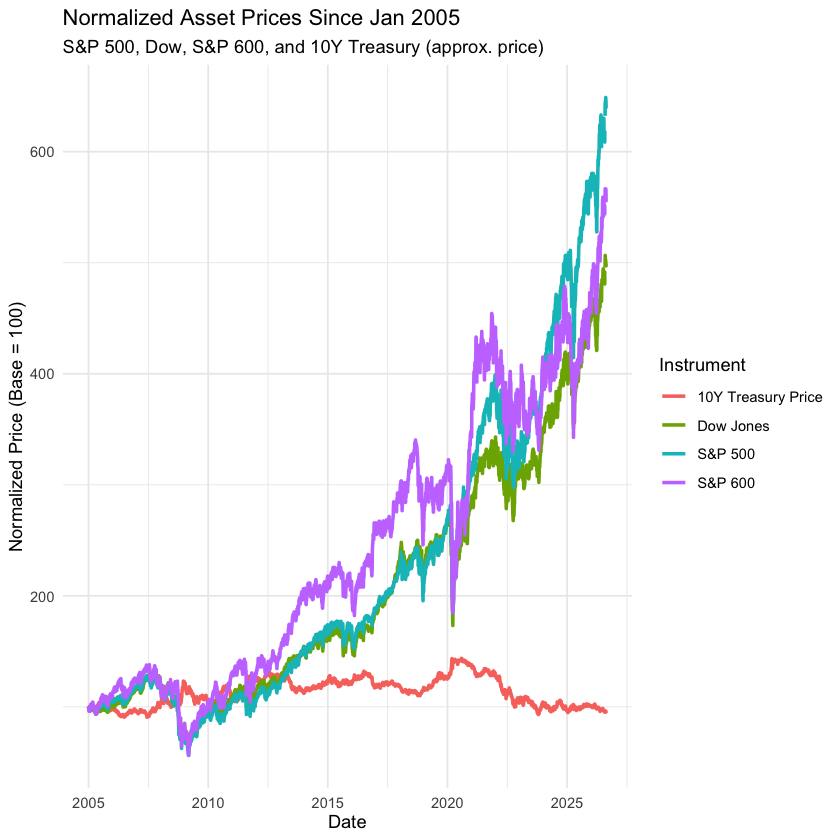

In [11]:
# Tickers
tickers <- c("^GSPC", "^DJI", "^SP600", "^TNX")

labels <- c("^GSPC" = "S&P 500",
            "^DJI" = "Dow Jones",
            "^SP600" = "S&P 600",
            "^TNX" = "10Y Treasury Price")

# Dates
start_date <- as.Date("2005-01-01")
end_date <- today()

# Download equity/index data from Yahoo Finance
equity_tickers <- setdiff(tickers, "^TNX")
market_data <- tq_get(equity_tickers,
                      from = start_date,
                      to = end_date,
                      get = "stock.prices")

# Yahoo Finance no longer serves long historical daily data for ^TNX (only
# the last ~20 trading days, regardless of the requested range), so we get
# the 10-year Treasury yield directly from FRED (DGS10) instead
tnx_fred <- read.csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10")
tnx_fred <- tnx_fred |>
  transmute(symbol = "^TNX",
            date = as.Date(observation_date),
            adjusted = DGS10) |>
  filter(date >= start_date, date <= end_date, !is.na(adjusted))

market_data <- bind_rows(market_data, tnx_fred)

# Convert TNX yield to bond price
bond_price_data <- market_data |>
  filter(symbol == "^TNX") |>
  mutate(
    label = labels[symbol],  # assign label before changing symbol
    adjusted = 100 / (1 + adjusted / 100)^10,
    symbol = "10Y Treasury Price"  # change symbol last
  )

# Replace TNX data with computed prices
equity_data <- market_data |>
  filter(symbol != "^TNX") |>
  mutate(label = labels[symbol])

# Combine
full_data <- bind_rows(equity_data, bond_price_data)

# Normalize
normalized_data <- full_data |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    base_value = first(adjusted),
    norm_price = adjusted / base_value * 100
  ) |>
  ungroup()

# Plot
ggplot(normalized_data, aes(x = date, y = norm_price, color = label)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Normalized Asset Prices Since Jan 2005",
    subtitle = "S&P 500, Dow, S&P 600, and 10Y Treasury (approx. price)",
    x = "Date",
    y = "Normalized Price (Base = 100)",
    color = "Instrument"
  ) +
  theme_minimal()


---
# 📉 Tendencias lineales como aproximación de la trayectoria de largo plazo

Las series financieras presentan fluctuaciones importantes a través del tiempo. Para resumir su comportamiento general, agregaremos una **tendencia lineal** a cada serie normalizada.

Para cada instrumento estimaremos:

$$Y_{i,t}=\alpha_i+\beta_i t+\varepsilon_{i,t}$$

donde:

* $Y_{i,t}$ es el nivel normalizado del instrumento $i$ en la fecha $t$;
* $\alpha_i$ es el intercepto de la recta;
* $\beta_i$ representa la pendiente promedio de la serie;
* $t$ corresponde al número de días transcurridos desde el inicio de la muestra;
* $\varepsilon_{i,t}$ recoge las desviaciones de corto plazo respecto de la tendencia.

En el código, la tendencia se estima mediante una regresión lineal de `norm_price` sobre `days_since_start`. Posteriormente, la recta se desplaza verticalmente para que comience exactamente en el primer valor observado de la serie.

Este ajuste conserva la pendiente estimada, pero modifica el intercepto original de la regresión. De esta manera, tanto la serie normalizada como su tendencia comienzan en el mismo punto.

Una pendiente positiva indica que el nivel normalizado presenta, en promedio, una trayectoria creciente durante el período analizado. Una pendiente mayor representa un crecimiento promedio más rápido en unidades del índice normalizado por día.

La tendencia lineal nos permitirá:

* resumir la dirección general de cada serie;
* reducir visualmente el efecto de las fluctuaciones de corto plazo;
* comparar la trayectoria promedio de los distintos instrumentos;
* relacionar el crecimiento observado con el riesgo de cada serie.

> 💡 **Objetivo del análisis:** utilizaremos estas tendencias como una primera aproximación visual para evaluar si los instrumentos que presentan mayor riesgo también exhiben una trayectoria de crecimiento más pronunciada durante el período analizado.


### 📐 ¿Qué es un *Slope Chart*?

Un **slope chart** (o *slopegraph*) es un tipo de gráfico de líneas que compara el valor de una o varias series **entre solo dos puntos** —típicamente un inicio y un final—, uniendo ambos valores con una línea recta. A diferencia de un gráfico de línea tradicional, no importa la trayectoria intermedia: lo único que se representa es *hacia dónde* y *cuánto* cambió cada serie.

#### ¿Para qué se usan?

* Para comparar el cambio relativo entre varias categorías o instrumentos a la vez (por ejemplo, el retorno acumulado de distintos activos entre una fecha inicial y una final).
* Para identificar rápidamente qué series subieron, cuáles bajaron y en qué magnitud, mediante la pendiente de cada línea.
* Para rankings "antes vs. después": qué elemento pasó a liderar o quedó rezagado en el período.

#### ¿Por qué son útiles?

* **Simplicidad:** condensan la comparación en dos columnas de valores, evitando el ruido visual de series completas cuando solo interesa el cambio neto.
* **La pendiente comunica el mensaje:** una línea más inclinada salta a la vista como un cambio más grande, sin necesidad de leer los ejes con precisión.
* **Comparación simultánea:** permiten ordenar y comparar muchas series a la vez, algo que una tabla numérica dificulta y un gráfico de líneas completo puede saturar.
* **Complementan, no reemplazan:** son ideales cuando el objetivo es destacar la *dirección y magnitud del cambio*, no los valores absolutos exactos (para eso conviene un gráfico de barras).

#### 🔗 Referencias

* Knaflic, C. N. — [What is a slopegraph, how is it used, and what is it good for](https://www.storytellingwithdata.com/blog/2020/7/27/what-is-a-slopegraph) (*storytelling with data*)
* [Slopegraph con `ggplot2` usando `newggslopegraph()`](https://r-charts.com/evolution/newggslopegraph/) (*R CHARTS*)
* Keirstead, J. — [r-slopegraph: Edward Tufte-style slopegraphs con R y ggplot2](https://github.com/jkeirstead/r-slopegraph) (GitHub)

## 📉 Tendencias lineales

A continuación, agregaremos una **tendencia lineal** a cada una de las series normalizadas.

Estas líneas permitirán resumir la trayectoria promedio de largo plazo del **S&P 500**, el **S&P 600**, el **Dow Jones Industrial Average** y el **precio aproximado del Treasury a 10 años**.

> 💡 Las líneas continuas representan la evolución observada de cada serie, mientras que las líneas segmentadas muestran su tendencia lineal estimada.


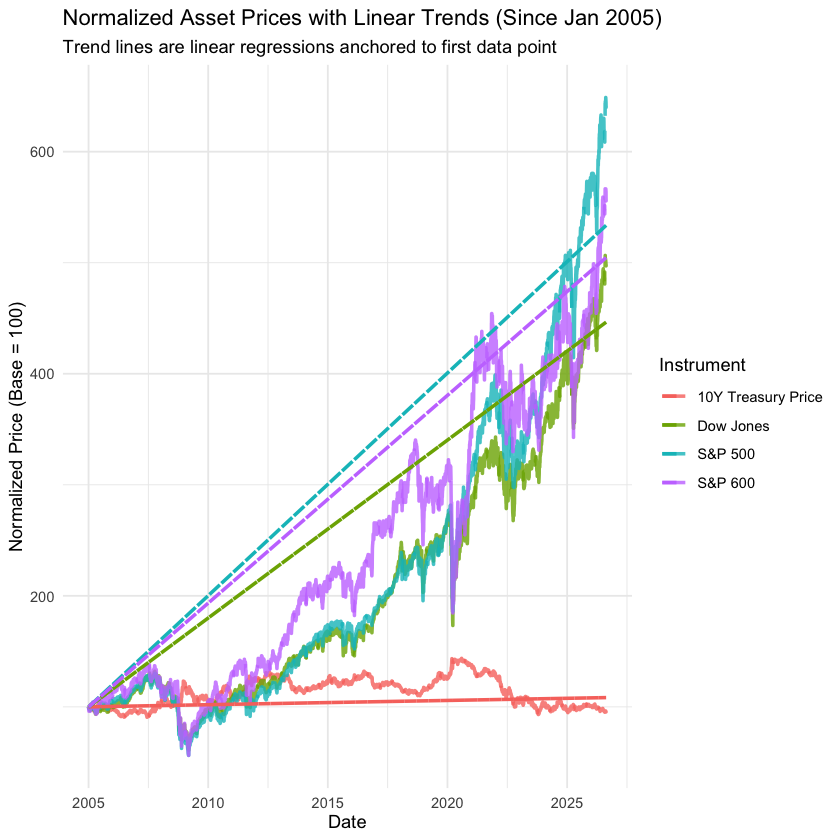

In [12]:
suppressWarnings(suppressPackageStartupMessages({
  library(tidyquant)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(lubridate)
  library(purrr)
}))

# Tickers
tickers <- c("^GSPC", "^DJI", "^SP600", "^TNX")

labels <- c("^GSPC" = "S&P 500",
            "^DJI" = "Dow Jones",
            "^SP600" = "S&P 600",
            "^TNX" = "10Y Treasury Price")

# Dates
start_date <- as.Date("2005-01-01")
end_date <- today()

# Download equity/index data from Yahoo Finance
equity_tickers <- setdiff(tickers, "^TNX")
market_data <- tq_get(equity_tickers,
                      from = start_date,
                      to = end_date,
                      get = "stock.prices")

# Yahoo Finance no longer serves long historical daily data for ^TNX (only
# the last ~20 trading days, regardless of the requested range), so we get
# the 10-year Treasury yield directly from FRED (DGS10) instead
tnx_fred <- read.csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10")
tnx_fred <- tnx_fred |>
  transmute(symbol = "^TNX",
            date = as.Date(observation_date),
            adjusted = DGS10) |>
  filter(date >= start_date, date <= end_date, !is.na(adjusted))

market_data <- bind_rows(market_data, tnx_fred)

# Convert TNX yield to bond price, assign label before changing symbol
bond_price_data <- market_data |>
  filter(symbol == "^TNX") |>
  mutate(
    label = labels[symbol],
    adjusted = 100 / (1 + adjusted / 100)^10,
    symbol = "10Y Treasury Price"
  )

# Other assets
equity_data <- market_data |>
  filter(symbol != "^TNX") |>
  mutate(label = labels[symbol])

# Combine data
full_data <- bind_rows(equity_data, bond_price_data)

# Normalize prices
normalized_data <- full_data |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    base_value = first(adjusted),
    norm_price = adjusted / base_value * 100
  ) |>
  ungroup()

# Compute linear trends, anchored to first value
trend_data <- normalized_data |>
  group_by(label) |>
  mutate(days_since_start = as.numeric(date - min(date))) |>
  group_modify(~ {
    model <- lm(norm_price ~ days_since_start, data = .x)
    trend <- predict(model, newdata = .x)
    shift <- .x$norm_price[1] - trend[1]
    .x$trend <- trend + shift
    .x
  }) |>
  ungroup()

# Plot
ggplot(trend_data, aes(x = date)) +
  geom_line(aes(y = norm_price, color = label), linewidth = 1, alpha = 0.8) +
  geom_line(aes(y = trend, color = label), linetype = "dashed", linewidth = 1) +
  labs(
    title = "Normalized Asset Prices with Linear Trends (Since Jan 2005)",
    subtitle = "Trend lines are linear regressions anchored to first data point",
    x = "Date",
    y = "Normalized Price (Base = 100)",
    color = "Instrument"
  ) +
  theme_minimal()


## 📊 Retornos históricos de cada serie

Hasta ahora hemos comparado la evolución de los niveles normalizados. A continuación, calcularemos los **retornos históricos** de cada serie para analizar con mayor precisión su desempeño y volatilidad.

El retorno simple entre dos períodos consecutivos se calcula como:

$$R_{i,t}=\frac{P_{i,t}}{P_{i,t-1}}-1$$

donde:

* $P_{i,t}$ es el nivel o precio del instrumento $i$ en la fecha $t$;
* $P_{i,t-1}$ es su nivel o precio en la fecha anterior;
* $R_{i,t}$ es el retorno observado entre ambos períodos.

Los retornos nos permitirán:

* comparar instrumentos expresados originalmente en escalas distintas;
* medir sus variaciones porcentuales;
* calcular retornos promedio;
* estimar volatilidad y otras medidas de riesgo;
* estudiar de manera más directa la relación entre riesgo y retorno.

> 💡 Mientras los niveles normalizados muestran la trayectoria acumulada de cada serie, los retornos permiten analizar sus cambios de un período a otro.


In [13]:
# 1. Extract ^TNX yield series (not the computed price)
tnx_yield <- market_data |>
  filter(symbol == "^TNX") |>
  arrange(date) |>
  mutate(
    rate = adjusted / 100  # Convert from "TNX units" to decimal yield
  )

# 2. Compute average interest rate (annualized)
avg_yield <- tnx_yield |>
  summarise(
    avg_rate = mean(rate, na.rm = TRUE),
    avg_percent = round(avg_rate * 100, 2)
  ) |>
  mutate(label = "10Y Treasury Yield")

# 3. Compute average log returns for other series
average_returns <- normalized_data |>
  filter(label != "10Y Treasury Price") |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    log_return = log(adjusted / lag(adjusted))
  ) |>
  summarise(
    avg_daily_log_return = mean(log_return, na.rm = TRUE),
    annual_log_return = avg_daily_log_return * 252,
    annual_percent = round(annual_log_return * 100, 2)
  ) |>
  ungroup() |>
  select(label, annual_percent)

# 4. Combine returns and yield
final_summary <- bind_rows(
  average_returns,
  avg_yield |> select(label, annual_percent = avg_percent)
)

suppressPackageStartupMessages(library(knitr))
suppressPackageStartupMessages(library(IRdisplay))

final_summary |>
  rename(Activo = label, `Retorno Anual (%)` = annual_percent) |>
  kable(format = "html", digits = 2, align = c("l", "r")) |>
  as.character() |>
  display_html()

Activo,Retorno Anual (%)
Dow Jones,7.37
S&P 500,8.54
S&P 600,7.89
10Y Treasury Yield,3.01


## 📏 Volatilidad de cada serie

La **volatilidad** mide cuánto fluctúan los retornos de un instrumento alrededor de su valor promedio. Una forma habitual de medirla es mediante la desviación estándar de los retornos:

$$\sigma_i=\sqrt{\frac{1}{T-1}\sum_{t=1}^{T}\left(R_{i,t}-\bar{R}_i\right)^2}$$

donde:

* $R_{i,t}$ es el retorno del instrumento $i$ en el período $t$;
* $\bar{R}_i$ es su retorno promedio;
* $T$ es el número de observaciones;
* $\sigma_i$ es la volatilidad histórica del instrumento.

Una volatilidad elevada indica que los retornos presentan fluctuaciones más amplias y, por lo tanto, mayor incertidumbre. En cambio, una volatilidad reducida implica que los retornos se mantienen más próximos a su promedio.

De acuerdo con la relación entre riesgo y retorno, esperaríamos que los instrumentos con mayor retorno promedio también presenten una mayor volatilidad. En términos generales, anticipamos el siguiente orden:

$$\text{Treasury}<\text{Dow Jones}\approx\text{S\&P 500}<\text{S\&P 600}$$
Por lo tanto, el **S&P 600** debería presentar la mayor volatilidad, debido a que representa empresas pequeñas, mientras que el **Treasury a 10 años** debería exhibir las menores fluctuaciones.

> ⚠️ **Precaución:** un mayor riesgo no garantiza un mayor retorno realizado en todos los períodos. La teoría sostiene que los inversionistas deberían exigir un mayor **retorno esperado** como compensación por asumir más riesgo, pero los retornos históricos pueden diferir de esa expectativa.

> 💡 **Hipótesis a contrastar:** comprobaremos si las series que han generado mayores retornos históricos también muestran una mayor dispersión de sus retornos.


In [14]:
# For equity 
returns_summary <- normalized_data |>
  filter(label != "10Y Treasury Price") |>
  group_by(label) |>
  arrange(date) |>
  mutate(
    log_return = log(adjusted / lag(adjusted))
  ) |>
  summarise(
    avg_daily_log_return = mean(log_return, na.rm = TRUE),
    sd_daily_log_return = sd(log_return, na.rm = TRUE),
    annual_return = avg_daily_log_return * 252,
    annual_volatility = sd_daily_log_return * sqrt(252),
    return_percent = round(annual_return * 100, 2),
    vol_percent = round(annual_volatility * 100, 2)
  ) |>
  select(label, return_percent, vol_percent)

# For 10Y Treasury yield (raw ^TNX)
tnx_stats <- market_data |>
  filter(symbol == "^TNX") |>
  mutate(
    yield = adjusted / 100  # Convert to decimal
  ) |>
  summarise(
    return_percent = round(mean(yield, na.rm = TRUE) * 100, 2),
    vol_percent = round(sd(yield, na.rm = TRUE) * 100, 2)
  ) |>
  mutate(label = "10Y Treasury Yield") |>
  select(label, return_percent, vol_percent)

# Combine everything and rank by risk, from lowest to highest volatility
final_summary <- bind_rows(returns_summary, tnx_stats) |>
  arrange(vol_percent) |>
  transmute(
    `Ranking Riesgo` = row_number(),
    Activo = label,
    `Retorno Anual (%)` = return_percent,
    `Volatilidad Anual (%)` = vol_percent
  )

# Display as a clean, publication-style HTML table, ordered from lowest to highest risk
suppressPackageStartupMessages(library(knitr))
suppressPackageStartupMessages(library(IRdisplay))

display_html(as.character(
  kable(final_summary, format = "html", align = c("c", "l", "r", "r"))
))

Ranking Riesgo,Activo,Retorno Anual (%),Volatilidad Anual (%)
1,10Y Treasury Yield,3.01,1.14
2,Dow Jones,7.37,17.98
3,S&P 500,8.54,19.05
4,S&P 600,7.89,23.73
